In [ ]:
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import butter, filtfilt, find_peaks

# -----------------------------
# Upload Widget
# -----------------------------
data = None

uploader = widgets.FileUpload(accept=".csv", multiple=False)
display(uploader)

# Function to load uploaded CSV
def load_file(change):
    global data
    if uploader.value:
        uploaded_file = list(uploader.value.values())[0]  # get the uploaded file
        content = uploaded_file['content']
        data = pd.read_csv(io.BytesIO(content))          # read into pandas
        print("File uploaded successfully!")            # ✅ inside string
        print("Columns found:", data.columns)

# Observe the upload event
uploader.observe(load_file, names='value')

FileUpload(value={}, accept='.csv', description='Upload')

File uploaded successfully!
Columns found: Index(['insole', 'foot', 'timestamp', 'seq', 'acx', 'acy', 'acz', 'gyrx',
       'gyry', 'gyrz', 'p_toe_1_f', 'p_toe_1_b', 'p_toe_3', 'p_toe_5',
       'p_arc_i', 'p_arc_o', 'p_heel_i', 'p_heel_o', 'roll', 'pitch', 'yaw'],
      dtype='object')


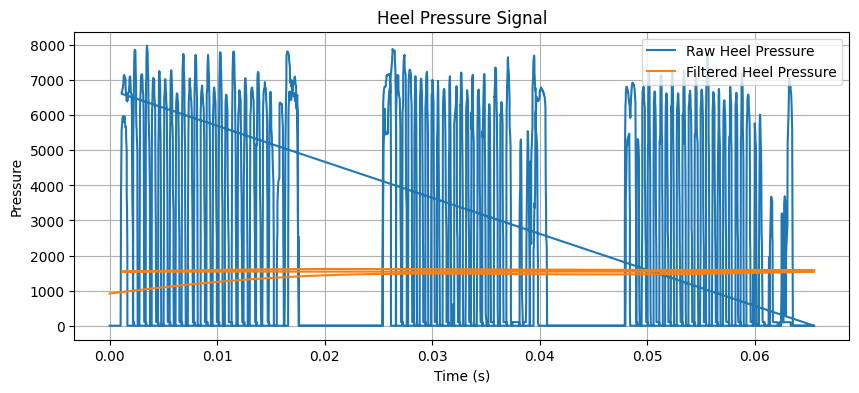

Heel Strikes Detected: 1
Cadence (steps/min): nan
Stride Time Variability (s): nan


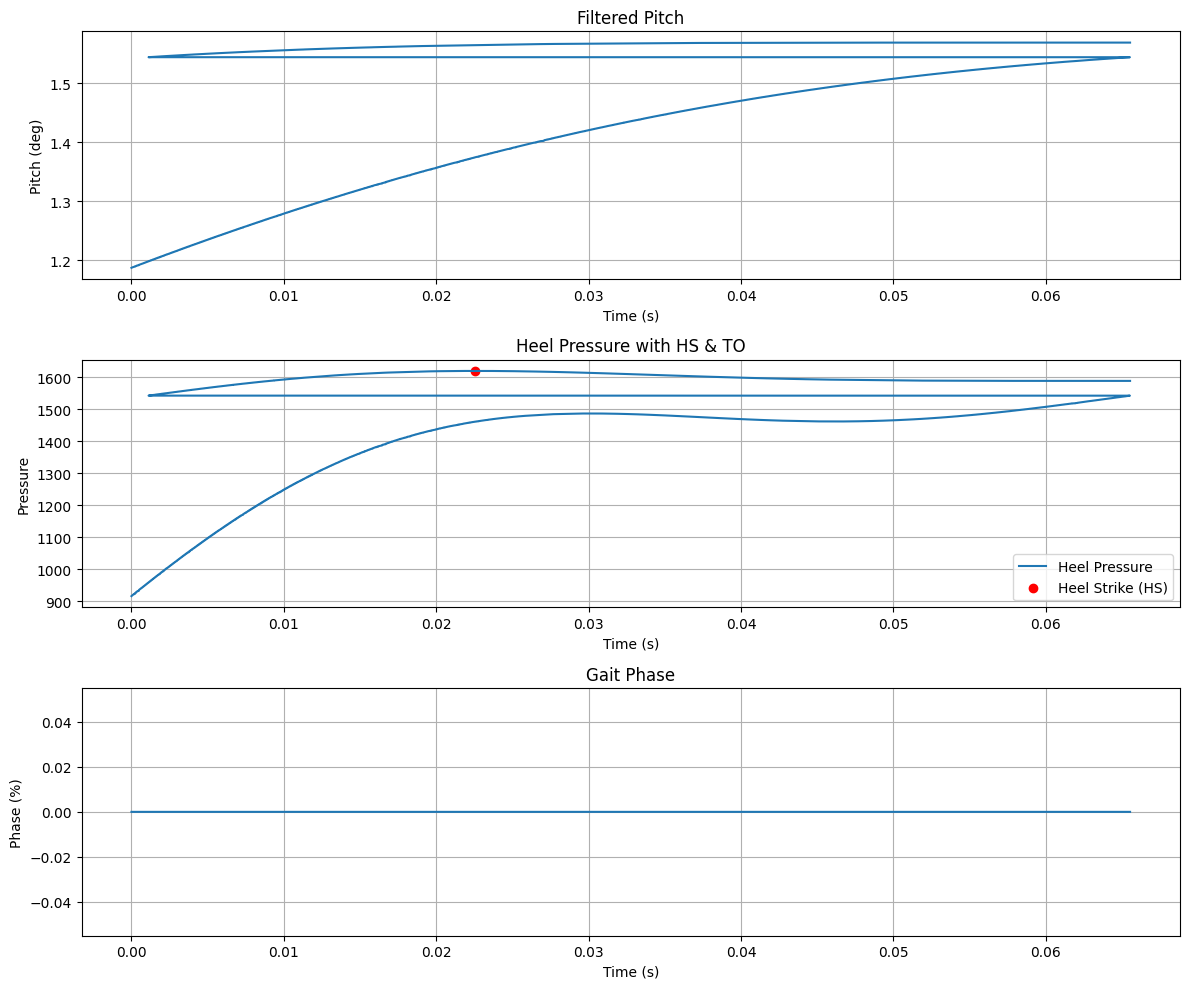

In [ ]:
# -----------------------------
# Extract signals
# -----------------------------
time = data["timestamp"].values
pitch = data["pitch"].values
heel_pressure = data["p_heel_i"].values + data["p_heel_o"].values

# Convert timestamp to seconds
time = (time - time[0]) / 1000

# -----------------------------
# Low-pass filter function
# -----------------------------
def butter_lowpass(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)

# Sampling frequency
fs = 1 / np.mean(np.diff(time))

# Filter signals
pitch_filtered = butter_lowpass(pitch, cutoff=6, fs=fs)
heel_filtered = butter_lowpass(heel_pressure, cutoff=25, fs=fs)  # higher cutoff preserves peaks

# -----------------------------
# Visual check of heel pressure
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(time, heel_pressure, label='Raw Heel Pressure')
plt.plot(time, heel_filtered, label='Filtered Heel Pressure')
plt.title("Heel Pressure Signal")
plt.xlabel("Time (s)")
plt.ylabel("Pressure")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Heel Strike (HS) detection
# -----------------------------
threshold = 0.2 * np.max(heel_filtered)  # dynamic threshold: 20% of max
peaks, _ = find_peaks(heel_filtered, distance=fs*0.5, height=threshold, prominence=0.1*np.std(heel_filtered))
peaks = peaks.astype(int)
print(f"Heel Strikes Detected: {len(peaks)}")

# -----------------------------
# Toe-Off (TO) detection
# -----------------------------
toe_offs = []
if len(peaks) > 1:
    for i in range(len(peaks)-1):
        segment = heel_filtered[peaks[i]:peaks[i+1]]
        to_idx = np.argmin(segment) + peaks[i]
        toe_offs.append(to_idx)
toe_offs = np.array(toe_offs, dtype=int)

# -----------------------------
# Gait Phase (0–100%)
# -----------------------------
phase = np.zeros_like(time)
if len(peaks) > 1:
    for i in range(len(peaks)-1):
        phase[peaks[i]:peaks[i+1]] = np.linspace(0, 100, peaks[i+1]-peaks[i])

# -----------------------------
# Metrics
# -----------------------------
if len(peaks) > 1:
    stride_times = np.diff(time[peaks])
    cadence = 60 / np.mean(stride_times)
    stride_variability = np.std(stride_times)
else:
    stride_times = []
    cadence = np.nan
    stride_variability = np.nan

print(f"Cadence (steps/min): {cadence:.2f}")
print(f"Stride Time Variability (s): {stride_variability:.3f}")

# -----------------------------
# Plot Results
# -----------------------------
plt.figure(figsize=(12,10))

# 1. Pitch
plt.subplot(3,1,1)
plt.plot(time, pitch_filtered, label="Filtered Pitch")
plt.title("Filtered Pitch")
plt.xlabel("Time (s)")
plt.ylabel("Pitch (deg)")
plt.grid(True)

# 2. Heel Pressure with HS and TO
plt.subplot(3,1,2)
plt.plot(time, heel_filtered, label="Heel Pressure")
if len(peaks) > 0:
    plt.scatter(time[peaks], heel_filtered[peaks], color='red', label="Heel Strike (HS)")
if len(toe_offs) > 0:
    plt.scatter(time[toe_offs], heel_filtered[toe_offs], color='green', label="Toe-Off (TO)")
plt.title("Heel Pressure with HS & TO")
plt.xlabel("Time (s)")
plt.ylabel("Pressure")
plt.legend()
plt.grid(True)

# 3. Gait Phase
plt.subplot(3,1,3)
plt.plot(time, phase, label="Gait Phase (0–100%)")
plt.title("Gait Phase")
plt.xlabel("Time (s)")
plt.ylabel("Phase (%)")
plt.grid(True)

plt.tight_layout()
plt.show()